                                               title  \
0  Been on both sides of a breakup now, here’s wh...   
1                        I saw my ex with his new gf   
2  Didn’t think losing someone who was already di...   
3            7 year relationship gone in an instant.   
4           When they come back it’s never worth it.   

                                                body  upvotes  comments_count  \
0  Two weeks ago I ended a nearly 2 year relation...      259             129   
1  I broke up with him on May 2nd. By June 6th he...       21              32   
2  We hadn’t really been "us" for a while. The te...       22               5   
3  I moved citys to live together and had our own...       54               9   
4  Post says it all. He came back after a few mon...      111              25   

             post_date            flair  \
0  2025-06-30 00:55:24              NaN   
1  2025-06-30 14:21:49              NaN   
2  2025-06-30 13:40:12              NaN   
3  2

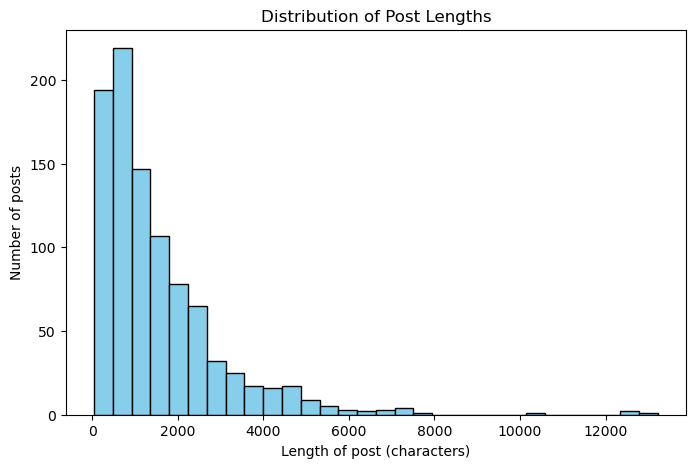

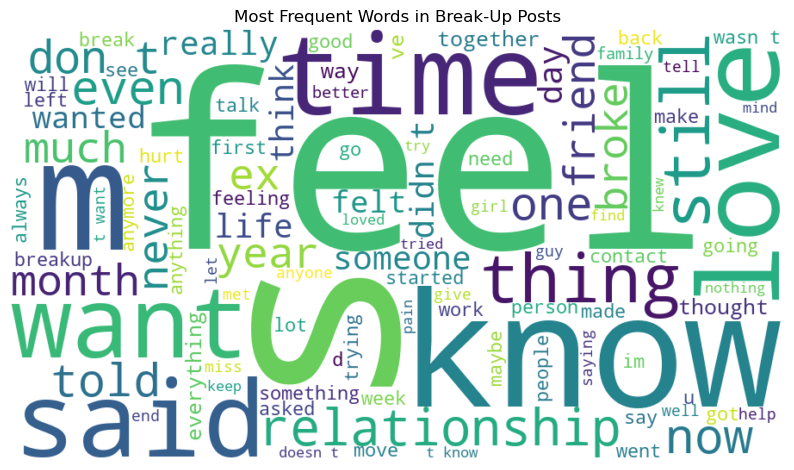


🔍 Example random posts after cleaning:

['no judgement 26f 26m has anyone ever cheated and regretted it ? i think my avoidant ex is but maybe he thought i would disrespect myself to stay for him to make his mind up. ( we were together going on 4 years ) the calls are still coming in 2 months after him ghosting me and having a letter in his bio for ig but also actively getting dissed on tinder ? why do people do this ? thinking someone will chase you by using another third party but it s just showing you d stand for nothing and fall for everything. childish. will like feedback :)', 'i need help, so me and my ex broke up around 3 months ago. we have been in contact pretty much everyday since, he says he doesn t want a relationship but is hanging out with some other girls and i m scared he s going to get with one. how can i prevent this and get him back. i was his first everything and we didn t breakup over something bad it was just a bad day and he didn t fight for me to stay. please he

In [9]:
# --------------------------------------------------------
# Step 0: IMPORT LIBRARIES
# --------------------------------------------------------
import pandas as pd      # For data handling (loading CSV, dataframes)
import re                # For text cleaning with regular expressions
import matplotlib.pyplot as plt   # For plotting charts/EDA visuals
from wordcloud import WordCloud   # For visualising frequent words

# --------------------------------------------------------
# Step 1: LOAD THE DATASET
# --------------------------------------------------------
# Read the CSV file into a pandas DataFrame
df = pd.read_csv(r'C:\Users\shubh\Capstone_Project\reddit_breakup_dataset_cleaned.csv')

# Check the first few rows of data to understand its structure
print(df.head())
print(df.info())

# --------------------------------------------------------
#  Step 2: COMBINE TITLE + BODY TEXT
# --------------------------------------------------------
# Both contain useful sentiment clues. 
# Some posts have strong emotional hints in the title, while the body gives details.

df['text'] = df['title'].fillna('') + " " + df['body'].fillna('')

# fillna('') replaces any missing title/body with an empty string 
# so concatenation won't break.

# --------------------------------------------------------
#  Step 3: CLEAN THE TEXT
# --------------------------------------------------------

def clean_text(text):
    """
    This function takes a string and cleans it step-by-step.
    """

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove non-ASCII characters (emojis, symbols)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)

    # Convert to lowercase 
    # (Lowercasing is useful for classical ML; for BERT, it depends on model whether it is cased or uncased)
    text = text.lower()

    # Remove extra spaces, tabs, newlines
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply cleaning function to every post
df['clean_text'] = df['text'].apply(clean_text)

# --------------------------------------------------------
# 📌 Step 4: REMOVE EMPTY OR TOO-SHORT TEXTS
# --------------------------------------------------------
# Some posts may be empty or meaningless after cleaning — remove them.
df = df[df['clean_text'].str.strip() != '']
df = df[df['clean_text'].str.len() > 20]  # Filters the DataFrame rows where the condition is True.
                                          #Only keeps rows where clean_text has more than 20 characters.

print(f" Dataset after cleaning: {df.shape[0]} posts remain")

# --------------------------------------------------------
# Step 5: EXPLORATORY DATA ANALYSIS
# --------------------------------------------------------

# 5.1 Length distribution of posts
df['text_length'] = df['clean_text'].apply(len)
plt.figure(figsize=(8,5))
plt.hist(df['text_length'], bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Post Lengths")
plt.xlabel("Length of post (characters)")
plt.ylabel("Number of posts")
plt.show()
#  This tells us if our dataset is dominated by short/long posts, which can affect model performance.

# 5.2 Generate a WordCloud
all_text = " ".join(df['clean_text'].tolist())

wc = WordCloud(width=900, height=500, background_color='white', max_words=100).generate(all_text)

plt.figure(figsize=(10,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in Break-Up Posts")
plt.show()
# Word clouds help spot recurring breakup-related words/slang quickly.

# 5.3 Peek at random samples
print("\n🔍 Example random posts after cleaning:\n")
print(df['clean_text'].sample(5, random_state=42).tolist())



In [ ]:
# Taking 200 samples from our dataset for manual labeling
df = pd.read_csv(r'C:\Users\shubh\Capstone_Project\reddit_breakup_dataset_cleaned.csv')
df['text'] = df['title'].fillna('') + " " + df['body'].fillna('')
sample = df[['text']].sample(200, random_state=42)
sample['label'] = ''
sample.to_csv("sample_for_labeling.csv", index=False)
# After labeling only 192 posts remained in which 8 posts were removed.


[notice] A new release of pip is available: 25.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shubh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\shubh\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

C:\Users\shubh\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:147: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\shubh\.cache\huggingface\hub\models--cardiffnlp--twitter-roberta-base-sentiment-latest. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.json: 0.00B [00:00, ?B/s]

...

Extracting SentiBERT embeddings (this may take some time)...


C:\Users\shubh\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\shubh\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Extracting SentiBERT embeddings (this may take some time)...


C:\Users\shubh\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\shubh\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



Final Results with Augmentation-aware Unified Pipeline:

Logistic Regression:
                precision    recall  f1-score   support

         anger       0.33      0.58      0.42        19
     confusion       0.42      0.27      0.33        30
longing_regret       0.48      0.53      0.50        64
        relief       0.21      0.27      0.24        15
       sadness       0.51      0.40      0.45        63

      accuracy                           0.43       191
     macro avg       0.39      0.41      0.39       191
  weighted avg       0.44      0.43      0.43       191

LogReg Confusion Matrix
[[11  4  1  0  3]
 [10 34  3  6 11]
 [ 5  9  8  1  7]
 [ 2  5  1  4  3]
 [ 5 19  6  8 25]]


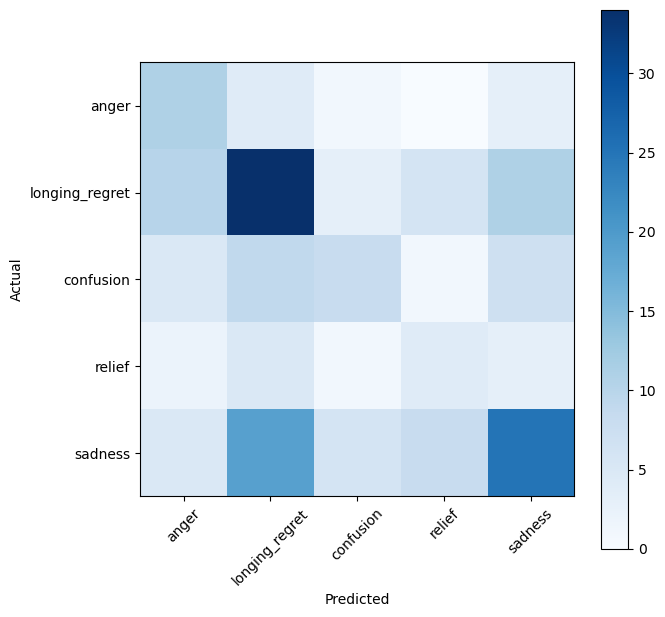


Linear SVM:
                precision    recall  f1-score   support

         anger       0.36      0.47      0.41        19
     confusion       0.35      0.27      0.30        30
longing_regret       0.42      0.48      0.45        64
        relief       0.20      0.13      0.16        15
       sadness       0.42      0.40      0.41        63

      accuracy                           0.39       191
     macro avg       0.35      0.35      0.35       191
  weighted avg       0.39      0.39      0.39       191

SVM Confusion Matrix
[[ 9  5  1  0  4]
 [ 8 31  5  4 16]
 [ 3  9  8  1  9]
 [ 1  6  1  2  5]
 [ 4 23  8  3 25]]


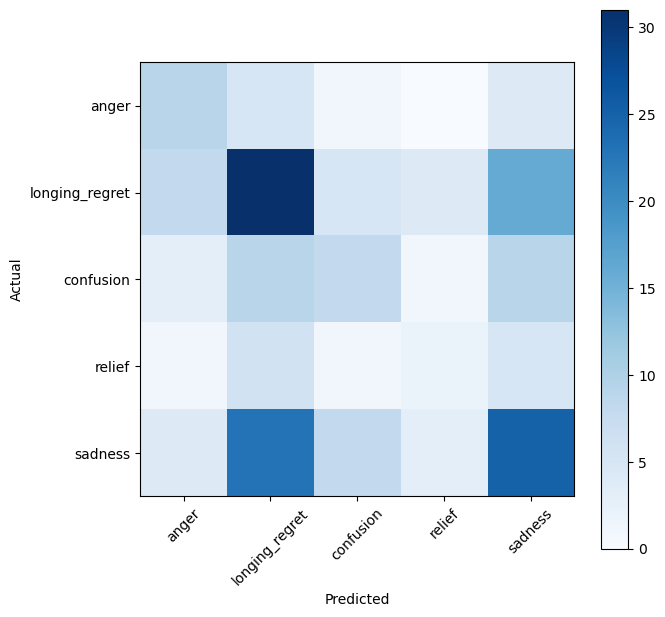


Random Forest:
                precision    recall  f1-score   support

         anger       0.28      0.58      0.37        19
     confusion       0.50      0.03      0.06        30
longing_regret       0.40      0.45      0.42        64
        relief       0.11      0.13      0.12        15
       sadness       0.46      0.41      0.43        63

      accuracy                           0.36       191
     macro avg       0.35      0.32      0.28       191
  weighted avg       0.40      0.36      0.34       191

RandomForest Confusion Matrix
[[11  4  0  0  4]
 [ 8 29  0  9 18]
 [ 5 16  1  1  7]
 [ 2  9  0  2  2]
 [14 15  1  7 26]]


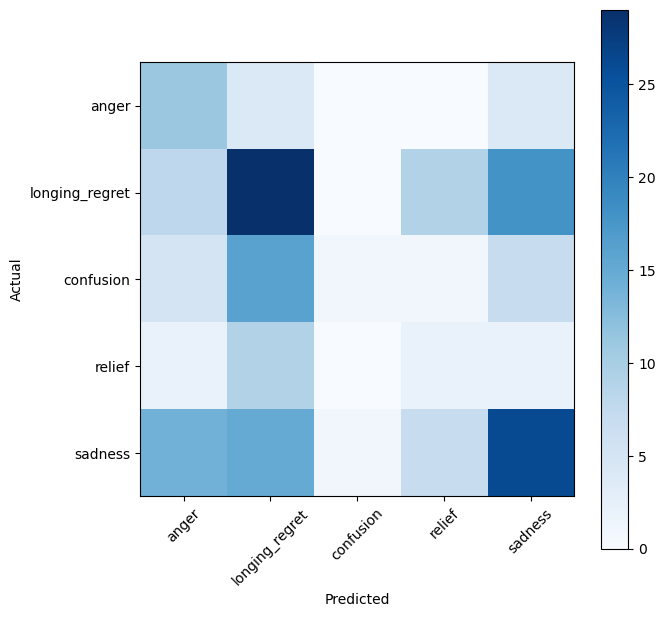


Gaussian Naive Bayes:
                precision    recall  f1-score   support

         anger       0.21      0.21      0.21        19
     confusion       0.18      0.13      0.15        30
longing_regret       0.39      0.61      0.47        64
        relief       0.33      0.07      0.11        15
       sadness       0.43      0.32      0.37        63

      accuracy                           0.36       191
     macro avg       0.31      0.27      0.26       191
  weighted avg       0.35      0.36      0.33       191

NaiveBayes Confusion Matrix
[[ 4  9  2  0  4]
 [ 5 39 10  2  8]
 [ 2 18  4  0  6]
 [ 2  2  2  1  8]
 [ 6 33  4  0 20]]


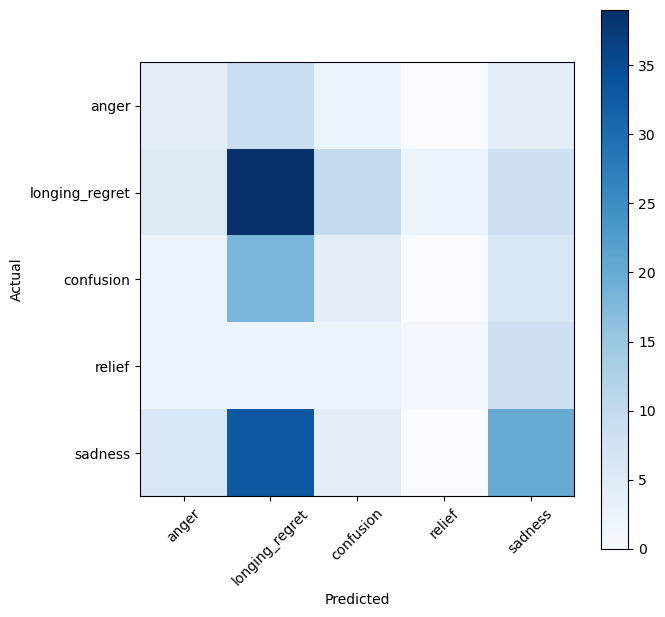

In [ ]:
#!pip install deep-translator
import pandas as pd
import numpy as np
import re
import emoji
import nltk
import random
import time
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from deep_translator import GoogleTranslator
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix
from scipy.sparse import hstack, csr_matrix
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel
import torch

nltk.download('stopwords')
nltk.download('wordnet')

# Preprocessing (emoji mapping, stopwords, lemmatization)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
def preprocess(text):
    text = emoji.demojize(text)
    text = re.sub(r':', ' ', text)
    text = re.sub(r'_', ' ', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)
    text = text.lower()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens).strip()

# Load GloVe embeddings
def load_glove_vectors(glove_file=r'C:/Users/shubh/glove.6B.100d.txt'):
    embeddings = {}
    with open(glove_file, encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            word = parts[0]
            vector = np.array(parts[1:], dtype='float32')
            embeddings[word] = vector
    return embeddings
glove_vectors = load_glove_vectors(r'C:/Users/shubh/glove.6B.100d.txt')
GLOVE_DIM = 100
def sentence_vector(text, embeddings, dim=GLOVE_DIM):
    words = text.split()
    vecs = [embeddings[w] for w in words if w in embeddings]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

# EDA Augmentation Functions
def synonym_replacement(sentence, n=2):
    words = sentence.split()
    new_words = words.copy()
    candidates = list(set([w for w in words if wordnet.synsets(w)]))
    random.shuffle(candidates)
    num_replaced = 0
    for word in candidates:
        synsets = wordnet.synsets(word)
        if not synsets:
            continue
        lemmas = synsets[0].lemmas()
        if not lemmas:
            continue
        synonym = lemmas[0].name()
        if synonym != word:
            new_words = [synonym if w == word else w for w in new_words]
            num_replaced += 1
        if num_replaced >= n:
            break
    return ' '.join(new_words)

def random_insertion(sentence, n=1):
    words = sentence.split()
    for _ in range(n):
        add_word(words)
    return ' '.join(words)

def add_word(words):
    counter = 0
    synonyms = []
    while len(synonyms) < 1 and counter < 10:
        random_word = random.choice(words)
        synsets = wordnet.synsets(random_word)
        counter += 1
        if not synsets:
            continue
        lemmas = synsets[0].lemmas()
        if not lemmas:
            continue
        synonyms.append(lemmas[0].name())
    if synonyms:
        idx = random.randint(0, len(words))
        words.insert(idx, synonyms[0])

def random_swap(sentence, n=1):
    words = sentence.split()
    if len(words) < 2:
        return sentence
    for _ in range(n):
        idx1, idx2 = random.sample(range(len(words)), 2)
        words[idx1], words[idx2] = words[idx2], words[idx1]
    return ' '.join(words)

def random_deletion(sentence, p=0.1):
    words = sentence.split()
    if len(words) == 1:
        return sentence
    new_words = [w for w in words if random.random() > p]
    if not new_words:
        return random.choice(words)
    return ' '.join(new_words)

def eda(sentence):
    methods = [synonym_replacement, random_insertion, random_swap, random_deletion]
    method = random.choice(methods)
    if method == synonym_replacement:
        return method(sentence, n=2)
    elif method == random_insertion or method == random_swap:
        return method(sentence, n=1)
    else:
        return method(sentence, p=0.1)

# Back-translation function (assumed same as before)
def back_translate(text, src='en', mid='fr', max_retries=3, delay=2, chunk_size=4000):
    def chunk_text(txt, size):
        return [txt[i:i+size] for i in range(0, len(txt), size)]
    chunks = chunk_text(text, chunk_size)
    back_chunks = []
    for chunk in chunks:
        for attempt in range(max_retries):
            try:
                trans = GoogleTranslator(source=src, target=mid).translate(chunk)
                back = GoogleTranslator(source=mid, target=src).translate(trans)
                back_chunks.append(back)
                time.sleep(delay)
                break
            except Exception as e:
                if attempt == max_retries-1:
                    back_chunks.append(chunk)
                else:
                    time.sleep(delay)
    return ' '.join(back_chunks)

# Load and preprocess dataset
df = pd.read_csv(r'C:/Users/shubh/sample_for_labeling.csv')
df['text'] = df['text'].apply(preprocess)
X = df['text']
y = df['label']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_true, all_pred_lr, all_pred_svm, all_pred_rf, all_pred_nb = [], [], [], [], []

minority_classes = ['anger', 'relief']

# Load SentiBERT tokenizer and model once before the loop
sentibert_tokenizer = AutoTokenizer.from_pretrained("cardiffnlp/twitter-roberta-base-sentiment-latest")
sentibert_model = AutoModel.from_pretrained("cardiffnlp/twitter-roberta-base-sentiment-latest")

def sentibert_vector(text):
    inputs = sentibert_tokenizer(text, return_tensors="pt", truncation=True, max_length=128, padding=True)
    with torch.no_grad():
        outputs = sentibert_model(**inputs)
    embedding = outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()
    return embedding

for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx].tolist(), X.iloc[test_idx].tolist()
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    augmented_texts = []
    augmented_labels = []

    # Augment training data only: heavier for minority classes
    
    for text, label in zip(X_train, y_train):
        augmented_texts.append(text)
        augmented_labels.append(label)
        if label in ['anger', 'relief']:
            # EDA: try 4-6 augmentations
           for _ in range(4):
               new_aug = eda(text)
               # Optionally, only keep augmented sample if it isn't too similar to original
               if new_aug != text:
                  augmented_texts.append(new_aug)
                  augmented_labels.append(label)
        # Back-translation or LLM-based paraphrasing: 2-3 versions
           for _ in range(2):
               try:
                  bt_text = back_translate(text)
                  if bt_text != text:
                     augmented_texts.append(bt_text)
                     augmented_labels.append(label)
               except Exception as e:
                      print(f"Back-translation error: {e}")
        # (Optional) Add GPT-based paraphrasing here as well


    # Generate features on augmented training data and test data (no augmentation on test)
    vectorizer_word = TfidfVectorizer(max_features=4000, ngram_range=(1,3), analyzer='word')
    vectorizer_char = TfidfVectorizer(max_features=4000, ngram_range=(2,5), analyzer='char_wb')
    tfidf_word_train = vectorizer_word.fit_transform(augmented_texts)
    tfidf_char_train = vectorizer_char.fit_transform(augmented_texts)
    tfidf_word_test = vectorizer_word.transform(X_test)
    tfidf_char_test = vectorizer_char.transform(X_test)
    tfidf_train = hstack([tfidf_word_train, tfidf_char_train])
    tfidf_test = hstack([tfidf_word_test, tfidf_char_test])

    glove_train = np.vstack([sentence_vector(t, glove_vectors) for t in augmented_texts])
    glove_test = np.vstack([sentence_vector(t, glove_vectors) for t in X_test])

    # Extract SentiBERT embeddings
    print("Extracting SentiBERT embeddings (this may take some time)...")
    sentibert_train = np.vstack([sentibert_vector(t) for t in augmented_texts])
    sentibert_test = np.vstack([sentibert_vector(t) for t in X_test])

    # Convert dense embeddings to sparse format for concatenation
    sentibert_train_sparse = csr_matrix(sentibert_train)
    sentibert_test_sparse = csr_matrix(sentibert_test)

    # Concatenate all features
    X_train_features = hstack([tfidf_train, glove_train, sentibert_train_sparse])
    X_test_features = hstack([tfidf_test, glove_test, sentibert_test_sparse])

    class_weight_dict = {
    'anger': 2.0,
    'relief': 7.0,  
    'confusion': 1.0,
    'longing_regret': 1.0,
    'sadness': 1.0}




    # Logistic Regression
    model_lr = LogisticRegression(class_weight=class_weight_dict, max_iter=1000, solver='liblinear', random_state=42)
    model_lr.fit(X_train_features, augmented_labels)
    y_pred_lr = model_lr.predict(X_test_features)

    # Linear SVM
    model_svm = LinearSVC(class_weight=class_weight_dict, max_iter=1000, random_state=42)
    model_svm.fit(X_train_features, augmented_labels)
    y_pred_svm = model_svm.predict(X_test_features)

    # Random Forest
    model_rf = RandomForestClassifier(class_weight=class_weight_dict, n_estimators=100, random_state=42, n_jobs=-1)
    model_rf.fit(X_train_features.toarray(), augmented_labels)
    y_pred_rf = model_rf.predict(X_test_features.toarray())

    # Gaussian Naive Bayes
    model_nb = GaussianNB()
    model_nb.fit(X_train_features.toarray(), augmented_labels)
    y_pred_nb = model_nb.predict(X_test_features.toarray())

    all_true.extend(y_test)
    all_pred_lr.extend(y_pred_lr)
    all_pred_svm.extend(y_pred_svm)
    all_pred_rf.extend(y_pred_rf)
    all_pred_nb.extend(y_pred_nb)

##########
# Step 5: Results & Error Analysis
##########
def print_confusion(y_true, y_pred, classes, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    print(title)
    print(cm)
    fig, ax = plt.subplots(figsize=(7,7))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(np.arange(len(classes)))
    ax.set_yticks(np.arange(len(classes)))
    ax.set_xticklabels(classes, rotation=45)
    ax.set_yticklabels(classes)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    plt.colorbar(im)
    plt.show()

print("\nFinal Results with Augmentation-aware Unified Pipeline:")

print("\nLogistic Regression:")
print(classification_report(all_true, all_pred_lr))
print_confusion(all_true, all_pred_lr, list(df['label'].unique()), title="LogReg Confusion Matrix")

print("\nLinear SVM:")
print(classification_report(all_true, all_pred_svm))
print_confusion(all_true, all_pred_svm, list(df['label'].unique()), title="SVM Confusion Matrix")

print("\nRandom Forest:")
print(classification_report(all_true, all_pred_rf))
print_confusion(all_true, all_pred_rf, list(df['label'].unique()), title="RandomForest Confusion Matrix")

print("\nGaussian Naive Bayes:")
print(classification_report(all_true, all_pred_nb))
print_confusion(all_true, all_pred_nb, list(df['label'].unique()), title="NaiveBayes Confusion Matrix")
